# 1.2 Scoring regression: MSE, explained variance and R²

A toy walk-through that scores a deliberately *naive* regressor, so the three regression metrics land before any real model does. We reuse the same predict → score → improve loop from 1.1, but for **continuous** outputs.


In [1]:
import numpy as np
from sklearn import metrics

## Fix the seed of the RNG


In [2]:
rseed = np.random.seed(42)

### 📊 **Scoring regressors**


These three metrics measure how close the predicted labels are to the regression line of the true labels.



1.   Mean Squared Error (mse)
2.   Explained variance
3.   R squared


### Create new mock dataset: Assume data has "best-fit" like sine wave.


### First generate 100 equally spaced x values between 0 and 10:


In [3]:
samples = 100
x = np.linspace(0, 10, samples) #generate samples of x
print(x)

[ 0.          0.1010101   0.2020202   0.3030303   0.4040404   0.50505051
  0.60606061  0.70707071  0.80808081  0.90909091  1.01010101  1.11111111
  1.21212121  1.31313131  1.41414141  1.51515152  1.61616162  1.71717172
  1.81818182  1.91919192  2.02020202  2.12121212  2.22222222  2.32323232
  2.42424242  2.52525253  2.62626263  2.72727273  2.82828283  2.92929293
  3.03030303  3.13131313  3.23232323  3.33333333  3.43434343  3.53535354
  3.63636364  3.73737374  3.83838384  3.93939394  4.04040404  4.14141414
  4.24242424  4.34343434  4.44444444  4.54545455  4.64646465  4.74747475
  4.84848485  4.94949495  5.05050505  5.15151515  5.25252525  5.35353535
  5.45454545  5.55555556  5.65656566  5.75757576  5.85858586  5.95959596
  6.06060606  6.16161616  6.26262626  6.36363636  6.46464646  6.56565657
  6.66666667  6.76767677  6.86868687  6.96969697  7.07070707  7.17171717
  7.27272727  7.37373737  7.47474747  7.57575758  7.67676768  7.77777778
  7.87878788  7.97979798  8.08080808  8.18181818  8

### Real data is often noisy. Create a jitter noise y_true function by adding random noise to the sin function


In [4]:

noisy_x = np.random.rand(x.size) #generate samples of noise between 0 and 1 (same amount as x)
print(noisy_x)
y_true = np.sin(x) + noisy_x - 0.5

[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258 0.02058449 0.96990985
 0.83244264 0.21233911 0.18182497 0.18340451 0.30424224 0.52475643
 0.43194502 0.29122914 0.61185289 0.13949386 0.29214465 0.36636184
 0.45606998 0.78517596 0.19967378 0.51423444 0.59241457 0.04645041
 0.60754485 0.17052412 0.06505159 0.94888554 0.96563203 0.80839735
 0.30461377 0.09767211 0.68423303 0.44015249 0.12203823 0.49517691
 0.03438852 0.9093204  0.25877998 0.66252228 0.31171108 0.52006802
 0.54671028 0.18485446 0.96958463 0.77513282 0.93949894 0.89482735
 0.59789998 0.92187424 0.0884925  0.19598286 0.04522729 0.32533033
 0.38867729 0.27134903 0.82873751 0.35675333 0.28093451 0.54269608
 0.14092422 0.80219698 0.07455064 0.98688694 0.77224477 0.19871568
 0.00552212 0.81546143 0.70685734 0.72900717 0.77127035 0.07404465
 0.35846573 0.11586906 0.86310343 0.62329813 0.33089802 0.06355835
 0.31098232 0.32518332 0.72960618 0.63755747 0.88721274 0.4722

# Matplotlib to visualize data:


In [5]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

Plot input data on same axis as best line (predicted model)


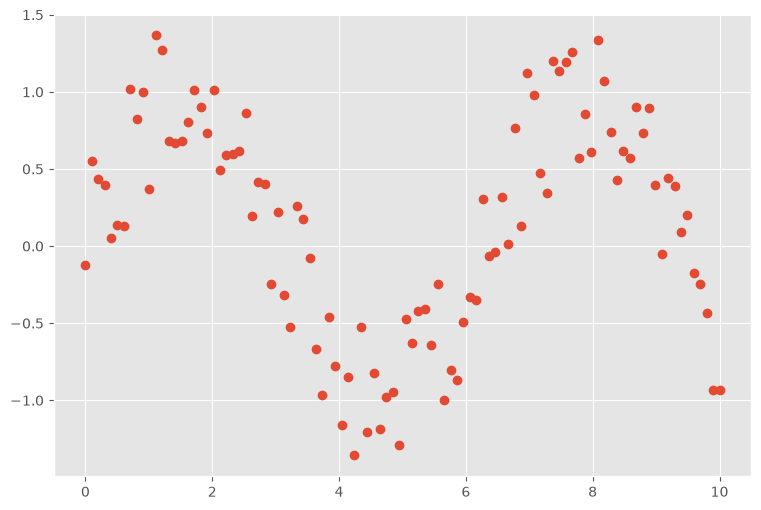

In [6]:
plt.figure(figsize=(9, 6))
plt.plot(x, y_true, 'o', label='Data')

###  Assume a clever model that figured out that it is a sine wave:


In [7]:

y_predict = np.sin(x)

### Plot
Optionally: plt.figure(figsize=(9, 6)) #to plot on new axis


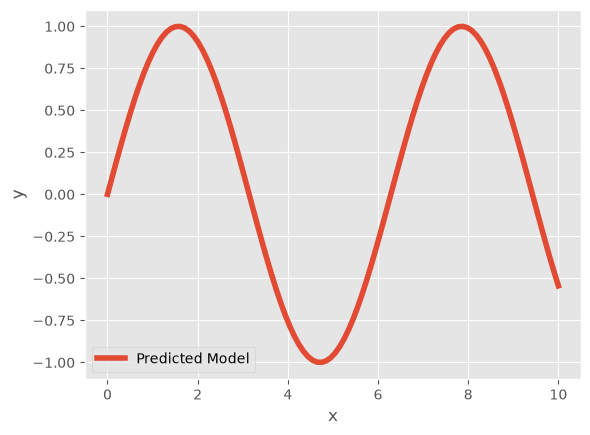

In [8]:
plt.plot(x, y_predict, linewidth=4, label='Predicted Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='lower left')
plt.show() # show both on same axis
# plt.savefig("sine.png")

# 📉 MSE: Mean Squared Error

* A simple metric to determine how good our model predictions are (by looking at how bad it is).
* For each datapoint, the difference between the predicted and actual `y` value is calculated and squared.


### 1. Simplest example: MSE on 2 points

Two real values and the model's two guesses – small enough to do in your head:

In [9]:
y_true_2    = np.array([2, 4])
y_predict_2 = np.array([3, 3])
mse_2 = np.mean((y_true_2 - y_predict_2) ** 2)
print(mse_2)   # each guess is off by 1 -> (1**2 + 1**2)/2 = 1

1.0


Each prediction is off by **1**, squaring keeps it positive, and averaging over 2 points gives **MSE = 1**. Now the same idea, generalised to $n$ points.

### End of simplest example

where $n$ is how many data points, $y_i$ is the true value of point $i$, $\hat{y}_i$ (read *y-hat*) is the model's prediction, and the **big sigma** $\Sigma$ is the *sum* symbol – add up everything it ranges over:

$$
\mathrm{MSE} = \frac{1}{\underbrace{n}_{\text{number of points}}} \;\underbrace{\sum_{i=1}^n}_{\substack{\text{add up}\\\text{over all points}}} \;\underbrace{(y_i - \hat{y}_i)^2}_{\text{squared error of } i}
$$

### MSE is thus calculated as follows:


In [10]:
np.mean((y_true - y_predict) ** 2)

np.float64(0.08850413823505532)

"Simply" use scikit-learn's built in MSE function instead:


In [11]:
mse = metrics.mean_squared_error(y_true, y_predict)
print(mse)

0.08850413823505532


### 📈 Explained variance

* Measures how much of the **scatter** in the data the model accounts for.
* Picture the extremes: if every data point sat exactly on the mean line $\bar{y}$, there would be no scatter at all and a single number – the mean – would predict every future point perfectly. Explained variance asks how close we are to that happy situation: the noisy part of $y$ that the model *leaves unexplained* is the remainder.


Here $\mathrm{Var}(\cdot)$ is the **variance** – how spread out a set of numbers is (the average squared distance from their mean). $\hat{y}$ is the model's prediction, $y$ the truth:

$$
\mathrm{EVS} = 1 - \underbrace{\frac{\mathrm{Var}(y - \hat{y})}{\mathrm{Var}(y)}}_{\substack{\text{leftover scatter}\\\text{÷ total scatter}}}
$$

Calculate the variance that exists between the predicted and ground truth to get the "fraction of variance explained":


In [12]:
ve = 1.0 - (np.var(y_true - y_predict) / np.var(y_true))

Again scikit-learn's built in function is used instead:


In [13]:
ve = metrics.explained_variance_score(y_true, y_predict)
print(ve)

0.8268093389805433


The coefficient of determination (R-squared) compares the mean squared error calculated earlier to the actual variance in the data:


where $\bar{y}$ (read *y-bar*) is the mean of the true values – our "no-model" baseline. $R^2$ compares the model's squared error against the error of just guessing the mean:

$$
R^2 = 1 - \frac{\overbrace{\sum_{i=1}^n (y_i - \hat{y}_i)^2}^{\text{model's squared error}}}{\underbrace{\sum_{i=1}^n (y_i - \bar{y})^2}_{\text{mean-baseline squared error}}}
$$

In [14]:
1.0 - mse / np.var(y_true)

np.float64(0.8250516587155616)

scikit-learn's built in function:


In [15]:
r2 = metrics.r2_score(y_true, y_predict)
print(r2)

0.8250516587155616


## 🔁 Visual appendix

Two self-contained visuals – each runs on its own data, so you can re-run a cell and watch the numbers update.

| # | Visual | What it shows |
| - | - | - |
| 1 | **R² = total variance split into explained + residual** | each point's error decomposed on the scatter – the picture behind $R^2$ |
| 2 | **The three sums of squares** | $SS_{\text{tot}} = SS_{\text{reg}} + SS_{\text{res}}$, so $R^2 = SS_{\text{reg}}/SS_{\text{tot}}$ |


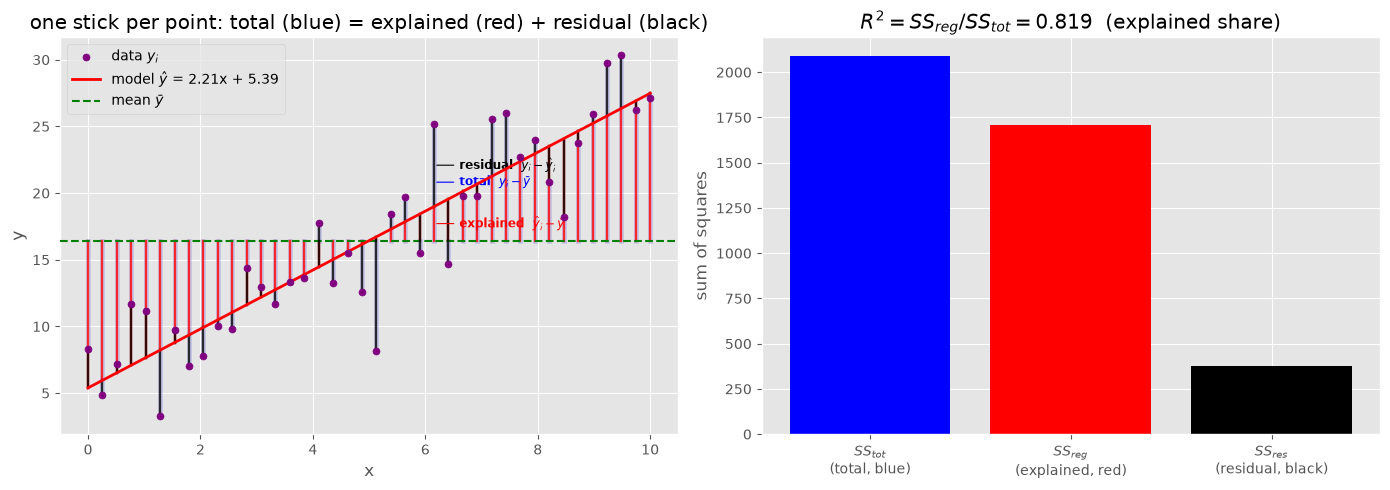

SS_tot = 2088.3   SS_reg = 1710.2   SS_res = 378.2   (check: 2088.3 = SS_tot)
R² = 0.819  (= 1 − SS_res/SS_tot = 0.819)


In [16]:
# [UPDATED] R² as a picture – one colour convention everywhere (matching the slides):
#   total = blue,  explained = red,  residual = black,  data = purple,  mean = green.
# Left  : each point splits into ONE vertical stick with three labelled pieces.
# Right : the same three colours reappear on the three sums-of-squares bars.
import numpy as np, matplotlib.pyplot as plt

np.random.seed(0)
x = np.linspace(0, 10, 40)
y = 2.5*x + 3 + np.random.randn(40)*3        # noisy line
yb = y.mean()
m_fit, c_fit = np.polyfit(x, y, 1)            # least-squares line (the model)
yhat = m_fit*x + c_fit

# The three sums of squares – R² is just their ratio.
SStot = np.sum((y - yb)**2)                   # total spread around the mean  (blue)
SSreg = np.sum((yhat - yb)**2)                # spread the model explains      (red)
SSres = np.sum((y - yhat)**2)                 # leftover error / residual      (black)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left: one stick per point, drawn faint-then-bold so the split is visible ----
ax[0].scatter(x, y, s=25, color='purple', zorder=5, label='data $y_i$')
ax[0].plot(x, yhat, color='red', lw=2, zorder=4, label=f'model $\\hat y$ = {m_fit:.2f}x + {c_fit:.2f}')
ax[0].axhline(yb, color='green', ls='--', lw=1.5, zorder=3, label='mean $\\bar y$')
for xi, yi, ypi in zip(x, y, yhat):
    ax[0].plot([xi, xi], [yb, yi],  color='blue',  alpha=.13, lw=3.6, zorder=1)  # total: ȳ → y   (faint, behind)
    ax[0].plot([xi, xi], [yb, ypi], color='red',    alpha=.80, lw=1.7, zorder=2) # explained: ȳ → ŷ
    ax[0].plot([xi, xi], [ypi, yi], color='black',  alpha=.80, lw=1.7, zorder=3) # residual:  ŷ → y
# label the three pieces on one point with a large positive residual so every segment is clearly separated
j = int(np.argmax(y - yhat))
xj, yj, ypj = x[j], y[j], yhat[j]
ax[0].annotate('total  $y_i-\\bar y$',        xy=(xj, (yb+yj)/2),  xytext=(xj+0.45, (yb+yj)/2),
               color='blue',  va='center', fontsize=8.5, fontweight='bold',
               arrowprops=dict(arrowstyle='-', color='blue',  lw=0.8))
ax[0].annotate('explained  $\\hat y_i-\\bar y$', xy=(xj, (yb+ypj)/2), xytext=(xj+0.45, (yb+ypj)/2),
               color='red',   va='center', fontsize=8.5, fontweight='bold',
               arrowprops=dict(arrowstyle='-', color='red',   lw=0.8))
ax[0].annotate('residual  $y_i-\\hat y_i$',  xy=(xj, (ypj+yj)/2), xytext=(xj+0.45, (ypj+yj)/2),
               color='black', va='center', fontsize=8.5, fontweight='bold',
               arrowprops=dict(arrowstyle='-', color='black', lw=0.8))
ax[0].set_title('one stick per point: total (blue) = explained (red) + residual (black)')
ax[0].set_xlabel('x'); ax[0].set_ylabel('y'); ax[0].legend(loc='upper left')

# ---- Right: same three colours – SS_tot = SS_reg + SS_res, so R² = SS_reg / SS_tot ----
ax[1].bar(['$SS_{tot}$\n(total, blue)', '$SS_{reg}$\n(explained, red)', '$SS_{res}$\n(residual, black)'],
          [SStot, SSreg, SSres], color=['blue', 'red', 'black'])
ax[1].set_title(r'$R^2 = SS_{reg}/SS_{tot} = %.3f$  (explained share)' % (SSreg/SStot))
ax[1].set_ylabel('sum of squares')
plt.tight_layout(); plt.show()

print(f"SS_tot = {SStot:.1f}   SS_reg = {SSreg:.1f}   SS_res = {SSres:.1f}   (check: {SSreg+SSres:.1f} = SS_tot)")
print(f"R² = {SSreg/SStot:.3f}  (= 1 − SS_res/SS_tot = {1 - SSres/SStot:.3f})")

### Analysis

**Colour key (same in both panels):** 🟦 blue = **total** variation, 🟥 red = **explained** by the model, ⬛ black = **residual** (left behind), 🟣 purple = the **data** point $y_i$, 🟩 green = the **mean** line $\bar y$.

The left panel draws **one vertical stick per point** and splits it into three pieces, all measured against the green mean line $\bar y$:

- 🟦 **blue** – the point's *total* distance from the mean: $(y_i - \bar y)$. This is the whole stick, from the green mean line up (or down) to the purple data dot. Stack all of these and you get $SS_{\text{tot}}$.
- 🟥 **red** – the part of that distance the model *explains*: $(\hat y_i - \bar y)$. This is the **lower segment**, measured from the green mean line to the red model line – i.e. how far the model moved off the mean.
- ⬛ **black** – the part the model *leaves behind*: $(y_i - \hat y_i)$. This is the **upper segment**, from the red model line up to the purple data dot – the raw prediction error.

Read a single stick **bottom-up**: green mean → red model (red, *explained*) → purple data (black, *residual*). The blue total is the whole stick behind them.

For every point those three distances satisfy the identity

$$\underbrace{(y_i - \bar y)}_{\text{🟦 total}} \;=\; \underbrace{(\hat y_i - \bar y)}_{\text{🟥 explained}} \;+\; \underbrace{(y_i - \hat y_i)}_{\text{⬛ residual}},$$

so summing the squares gives the same identity the right-hand bar chart shows:

$$SS_{\text{tot}} = SS_{\text{reg}} + SS_{\text{res}}.$$

$R^2$ is simply the **red share of the blue bar**:

$$R^2 = \frac{SS_{\text{reg}}}{SS_{\text{tot}}} = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}.$$

The two extremes anchor your intuition:

- $R^2 = 1$ means $SS_{\text{res}} = 0$ – every black stick vanishes, the purple dots sit exactly on the red line, the model fits perfectly.
- $R^2 = 0$ means $SS_{\text{reg}} = 0$ – the red sticks vanish, the model never leaves the green mean line, so it is no better than just guessing the mean.

Notice $R^2$ and **explained variance** are cousins, not twins: $R^2$ compares the model to the *mean line* via squared errors, while explained variance compares the *residuals'* variance to the data's variance. When the model is unbiased they agree; when the mean of the residuals is non-zero, $R^2$ can drop below the explained-variance score – which is why you saw `0.825` (R²) sit just below `0.827` (EVS) in the cells above.

### 🧠 Quick quiz

1. A model that always predicts the mean, $\hat y = \bar y$, for every row. What is its $R^2$? What is its MSE relative to the variance of $y$?
2. $R^2$ can go **negative**. Sketch a model so bad that $SS_{\text{res}} > SS_{\text{tot}}$. Why does MSE have no such ceiling?
3. Doubling every prediction $\hat y$. Which of {MSE, explained variance, $R^2$} change, and which stay the same?

4. **(Exam-style compare)** A classmate fits a 10-feature linear model and reports $R^2 = 0.91$; you fit a 2-feature model and report $R^2 = 0.88$. Your classmate claims their model is clearly better. Why is $R^2$ alone a weak basis for that claim, and what does adding more features to $R^2$ *always* do (mechanically) that makes it flattering?

<details><summary>Answers (click to reveal)</summary>

1. $\hat y = \bar y \Rightarrow SS_{\text{reg}}=0$ and $SS_{\text{res}}=SS_{\text{tot}}$, so $R^2 = 0$. Its MSE equals $\mathrm{Var}(y)$ (the squared spread around the mean) – predicting the mean is exactly what variance measures.
2. A line with the *right slope but wrong sign*, or a wildly biased model, can miss by more than the mean does: residuals bigger than total variation ⇒ $SS_{\text{res}} > SS_{\text{tot}}$ ⇒ $R^2 < 0$. MSE has no ceiling because it is an average *squared error* – scale the predictions up and the error grows without bound; $R^2$ is *normalised* by $SS_{\text{tot}}$, so it is the ratio that goes negative, not MSE.
3. Doubling $\hat y$ breaks the $\hat y \to \bar y$ relationship: **MSE** changes (errors roughly double then square), **explained variance** changes (residual variance grows), and **$R^2$** changes (can drop below 0). None stay the same – the mean line $\bar y$ is fixed, so moving predictions away from it disturbs all three.

4. $R^2$ **never decreases** when you add a feature – least squares can always use an extra coefficient to do at least as well on the training fit, so $R^2$ is mechanically flattering toward bigger models and does not penalise complexity. A 0.91 vs 0.88 gap on training data says nothing about *generalisation*; the 10-feature model may simply be overfitting. The honest comparison uses a held-out/test $R^2$ or **adjusted $R^2$** (which subtracts a per-feature penalty), or cross-validated MSE – the 2-feature model may well win out-of-sample even though its training $R^2$ is lower.

</details>
